# BRCA Subtype Classification
This notebook covers:
1. **EDA** — explore the raw data
2. **Model Results** — load results saved by each `src/train_*.py` script and display outputs

> **Before running sections 2+**, train models from terminal:
> ```bash
> cd src
> python train_random_forest.py
> python train_svm.py
> # python train_<any_new_model>.py
> ```

In [1]:
import sys
import pickle
import pandas as pd
import altair as alt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

class _LEWrapper(BaseEstimator, ClassifierMixin):
    """Notebook-local compatibility wrapper for legacy stacking pickles."""

    def __init__(self, estimator, le=None):
        self.estimator = estimator
        self.le = le

    def fit(self, X, y):
        self.le = LabelEncoder()
        self.le.fit(y)
        self.estimator.fit(X, self.le.transform(y))
        self.classes_ = self.le.classes_
        return self

    def predict(self, X):
        return self.le.inverse_transform(self.estimator.predict(X))

    def predict_proba(self, X):
        return self.estimator.predict_proba(X)

    def get_params(self, deep=True):
        return {"estimator": self.estimator, "le": self.le}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

sys.path.append("src")
from data_preprocessing import load_data, preprocess

alt.renderers.enable()


RendererRegistry.enable('default')

---
# 1. Exploratory Data Analysis

## Data Loading and Preview

In [2]:
data, clinic = load_data()

Preview of genetic sequence data

In [3]:
data.head()

,Ensembl_ID,TCGA-E9-A1NI-01A,TCGA-A1-A0SP-01A,TCGA-BH-A1EU-11A,TCGA-A8-A06X-01A,TCGA-E2-A14T-01A,TCGA-AC-A8OS-01A,TCGA-A8-A09K-01A,TCGA-OL-A5RY-01A,TCGA-BH-A0DG-01A,...,TCGA-BH-A0DT-11A,TCGA-E9-A1R0-01A,TCGA-BH-A0B6-01A,TCGA-B6-A0RN-01A,TCGA-A8-A09W-01A,TCGA-EW-A1P3-01A,TCGA-A7-A13F-11A,TCGA-A2-A0T6-01A,TCGA-A7-A5ZW-01A,TCGA-BH-A203-01A
0,ENSG00000242268.2,2.136175,0.000000,1.366653,0.000000,0.000000,8.460189,0.000000,0.000000,0.000000,...,6.271042,2.655369,0.000000,0.000000,0.000000,0.000000,12.200121,2.400749,0.000000,1.455457
1,ENSG00000270112.3,0.444602,0.108543,0.379255,0.000000,0.000000,0.000000,0.126752,0.000000,0.000000,...,0.000000,0.092110,0.222683,0.000000,0.248376,0.000000,0.000000,0.000000,0.151089,0.201949
2,ENSG00000167578.15,120.772270,87.749001,75.417573,93.460292,188.027995,129.685657,127.839992,114.870865,97.754686,...,99.844261,103.076824,218.082323,92.036286,41.643751,178.095525,65.848070,89.621045,116.841950,119.689776
3,ENSG00000273842.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,ENSG00000078237.5,130.195003,589.404468,97.898995,196.498809,96.495171,74.910318,89.468125,164.586674,109.453575,...,109.201664,124.731209,107.049049,77.411736,119.400389,95.149919,64.471363,126.679274,132.987996,293.296423


Preview of Clinic data

In [4]:
clinic.head()

,Patient ID,Sample ID,Diagnosis Age,Cancer Type,Sex,Subtype,Tumor Type
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,55,Invasive Breast Carcinoma,Female,BRCA_LumA,Infiltrating Lobular Carcinoma
1,TCGA-3C-AALI,TCGA-3C-AALI-01,50,Invasive Breast Carcinoma,Female,BRCA_Her2,Infiltrating Ductal Carcinoma
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,62,Invasive Breast Carcinoma,Female,BRCA_LumB,Infiltrating Ductal Carcinoma
3,TCGA-3C-AALK,TCGA-3C-AALK-01,52,Invasive Breast Carcinoma,Female,BRCA_LumA,Infiltrating Ductal Carcinoma
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,50,Invasive Breast Carcinoma,Female,BRCA_LumA,Infiltrating Lobular Carcinoma


## Counts of Samples per Subtype (raw clinic data)

In [5]:
clinic_summary = clinic.groupby("Subtype").size().rename("Count").reset_index()
clinic_summary

,Subtype,Count
0,BRCA_Basal,171
1,BRCA_Her2,78
2,BRCA_LumA,499
3,BRCA_LumB,197
4,BRCA_Normal,36


In [6]:
alt.Chart(clinic_summary).mark_bar().encode(
    alt.X("Subtype"),
    alt.Y("Count"),
    color="Subtype",
    tooltip=["Subtype", "Count"]
).properties(
    title="Number of Samples per Subtype",
    width=150,
    height=300
)

alt.Chart(...)

## Preprocessing

In [7]:
df = preprocess(data, clinic)

Subtype sample counts of the final cleaned dataset

In [8]:
df.groupby("Subtype").size().reset_index().rename(columns={0: "Count"})

,Subtype,Count
0,BRCA_Basal,168
1,BRCA_Her2,77
2,BRCA_LumA,490
3,BRCA_LumB,192
4,BRCA_Normal,35


## Gene Expression Scatter (two example genes)

In [9]:
to_plot = df[["Subtype", "ENSG00000242268.2", "ENSG00000270112.3"]]
to_plot.columns = ['Subtype', 'gene_one', 'gene_two']

alt.Chart(to_plot).mark_circle().encode(
    alt.X("gene_one", scale=alt.Scale(zero=False)),
    alt.Y("gene_two", scale=alt.Scale(zero=False)),
    color="Subtype",
    size="gene_one"
).facet(
    facet="Subtype",
    columns=2
)

alt.FacetChart(...)

---
# 2. Model Results
Each section below loads the `.pkl` file saved by the corresponding `src/train_*.py` script.\
To add a new model: train it with a new script, save its results dict to `models/`, then add a section below.

---
## 2.1 Random Forest

In [10]:
with open("models/rf_results.pkl", "rb") as f:
    rf = pickle.load(f)

print(f"Random Forest Accuracy: {rf['accuracy']:.4f}")

Random Forest Accuracy: 0.8601


### Accuracy vs Max Depth

In [11]:
max_depth_chart = alt.Chart(rf["max_depth_df"]).mark_line().encode(
    alt.X("max_depth", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["max_depth", "Accuracy"]
).properties(title="Random Forest Accuracy vs Max Depth")

max_depth_chart

alt.Chart(...)

### Accuracy vs n_estimators

In [12]:
estimate_chart = alt.Chart(rf["n_estimate_df"]).mark_line().encode(
    alt.X("n_estimator", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["n_estimator", "Accuracy"]
).properties(title="Random Forest Accuracy vs n_estimator")

max_depth_chart | estimate_chart

alt.HConcatChart(...)

### Confusion Matrix

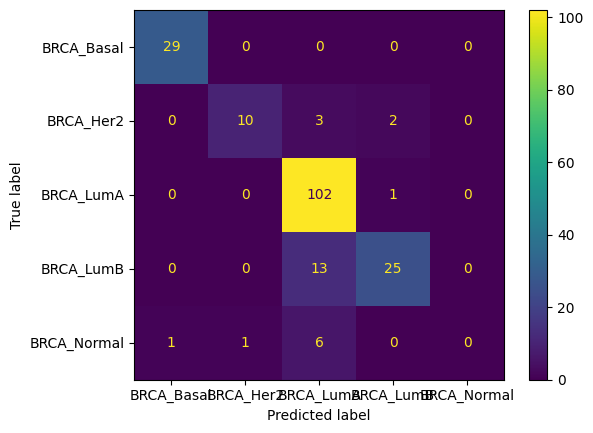

In [13]:
ConfusionMatrixDisplay(rf["conf_mat"], display_labels=rf["classes"]).plot()

**Random Forest Observations**\
The model is having trouble with predicting BRCA_Normal. This makes sense given that we have very few samples of this subtype.\
Also, the model is having problems with separating between BRCA_LumA and BRCA_LumB.

### Feature Importance (Top 10 Genes)

In [14]:
rf["feature_data"]

,Feature,Importance,Feature Names
0,ENSG00000129514.5,0.004904,DRAIC
1,ENSG00000225362.7,0.004067,TTC6
2,ENSG00000170312.14,0.004045,SLC7A13
3,ENSG00000154548.8,0.003963,DNAI7
4,ENSG00000080986.11,0.003809,CCNB2
5,ENSG00000142945.11,0.003766,CENPA
6,ENSG00000134830.5,0.003724,ESR1
7,ENSG00000257271.1,0.003625,RAB6C
8,ENSG00000259793.1,0.003561,CDC20
9,ENSG00000115163.13,0.003497,CCNE1


In [15]:
alt.Chart(rf["feature_data"]).mark_bar().encode(
    y=alt.Y("Feature Names", sort=alt.EncodingSortField(field="Importance", op="count", order="ascending"), title="Gene"),
    x=alt.X("Importance:Q"),
    color=alt.Color("Feature Names", title="Gene", legend=None),
    tooltip=["Feature Names", "Importance"]
)

alt.Chart(...)

---
## 2.2 Support Vector Machine (SVM)

In [16]:
with open("models/svm_results.pkl", "rb") as f:
    svm = pickle.load(f)

print(f"SVM Accuracy: {svm['accuracy']:.4f}")

SVM Accuracy: 0.6321


### Accuracy vs C Parameter

In [17]:
alt.Chart(svm["svm_class_df"]).mark_line().encode(
    alt.X("C parameter", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False))
).properties(title="SVM Accuracy vs C Parameter")

alt.Chart(...)

### Confusion Matrix

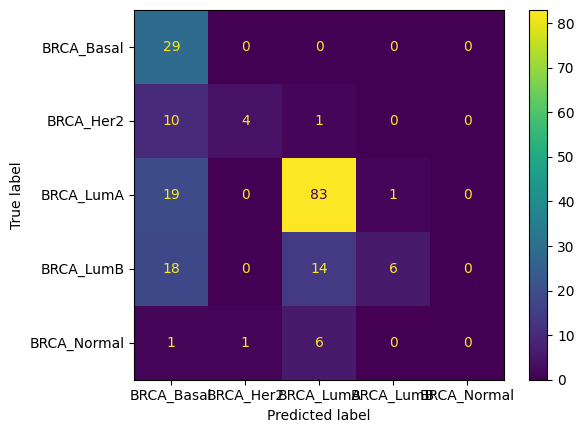

In [18]:
ConfusionMatrixDisplay(svm["conf_mat"], display_labels=svm["classes"]).plot()

**SVM Observation**\
The matrix shows that this model is not better than Random Forest in any subclassification.

---
## 2.3 Add New Model Here
1. Create `src/train_<model_name>.py` — train, evaluate, and save a results dict to `models/<model_name>_results.pkl`
2. Copy the block below and fill in your model's keys:

```python
with open("models/<model_name>_results.pkl", "rb") as f:
    my_model = pickle.load(f)

print(f"<Model> Accuracy: {my_model['accuracy']:.4f}")
ConfusionMatrixDisplay(my_model["conf_mat"], display_labels=my_model["classes"]).plot()
```

---
## 2.3 XGBoost

In [19]:
with open("models/xgb_results.pkl", "rb") as f:
    xgb = pickle.load(f)

print(f"XGBoost Accuracy: {xgb['accuracy']:.4f}")

XGBoost Accuracy: 0.8756


### Accuracy vs Max Depth

In [20]:
xgb_depth_chart = alt.Chart(xgb["max_depth_df"]).mark_line().encode(
    alt.X("max_depth", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["max_depth", "Accuracy"]
).properties(title="XGBoost Accuracy vs Max Depth")

xgb_depth_chart

alt.Chart(...)

### Accuracy vs n_estimators

In [21]:
xgb_estimate_chart = alt.Chart(xgb["n_estimate_df"]).mark_line().encode(
    alt.X("n_estimator", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["n_estimator", "Accuracy"]
).properties(title="XGBoost Accuracy vs n_estimator")

xgb_depth_chart | xgb_estimate_chart

alt.HConcatChart(...)

### Accuracy vs Learning Rate

In [22]:
alt.Chart(xgb["lr_df"]).mark_line(point=True).encode(
    alt.X("learning_rate", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["learning_rate", "Accuracy"]
).properties(title="XGBoost Accuracy vs Learning Rate")

alt.Chart(...)

### Confusion Matrix

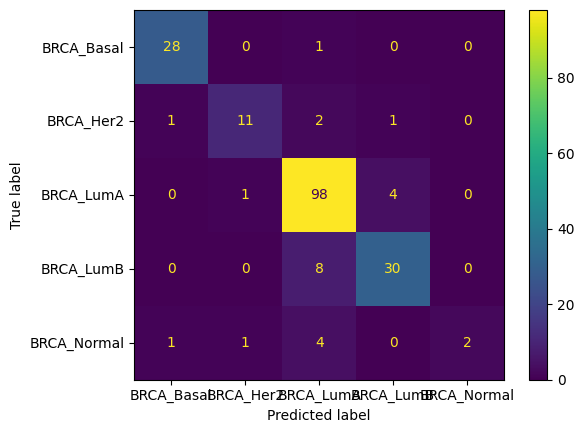

In [23]:
ConfusionMatrixDisplay(xgb["conf_mat"], display_labels=xgb["classes"]).plot()

### Feature Importance (Top 10 Genes)

In [24]:
xgb["feature_data"]

,Feature,Importance
0,ENSG00000115648.12,0.074549
1,ENSG00000141741.10,0.046685
2,ENSG00000115163.13,0.041674
3,ENSG00000164237.7,0.036457
4,ENSG00000165379.12,0.025813
5,ENSG00000233823.1,0.021734
6,ENSG00000104332.10,0.021162
7,ENSG00000280916.1,0.019084
8,ENSG00000248359.1,0.017959
9,ENSG00000138180.14,0.017614


In [25]:
alt.Chart(xgb["feature_data"]).mark_bar().encode(
    y=alt.Y("Feature", sort=alt.EncodingSortField(field="Importance", op="count", order="ascending"), title="Gene"),
    x=alt.X("Importance:Q"),
    color=alt.Color("Feature", legend=None),
    tooltip=["Feature", "Importance"]
).properties(title="XGBoost Top 10 Feature Importances")

alt.Chart(...)

---
## 2.4 LightGBM

In [26]:
with open("models/lgbm_results.pkl", "rb") as f:
    lgbm = pickle.load(f)

print(f"LightGBM Accuracy: {lgbm['accuracy']:.4f}")

LightGBM Accuracy: 0.8756


### Accuracy vs Max Depth

In [27]:
lgbm_depth_chart = alt.Chart(lgbm["max_depth_df"]).mark_line().encode(
    alt.X("max_depth", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["max_depth", "Accuracy"]
).properties(title="LightGBM Accuracy vs Max Depth")

lgbm_depth_chart

alt.Chart(...)

### Accuracy vs n_estimators

In [28]:
lgbm_estimate_chart = alt.Chart(lgbm["n_estimate_df"]).mark_line().encode(
    alt.X("n_estimator", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["n_estimator", "Accuracy"]
).properties(title="LightGBM Accuracy vs n_estimator")

lgbm_depth_chart | lgbm_estimate_chart

alt.HConcatChart(...)

### Accuracy vs Learning Rate

In [29]:
alt.Chart(lgbm["lr_df"]).mark_line(point=True).encode(
    alt.X("learning_rate", scale=alt.Scale(zero=False)),
    alt.Y("Accuracy", scale=alt.Scale(zero=False)),
    tooltip=["learning_rate", "Accuracy"]
).properties(title="LightGBM Accuracy vs Learning Rate")

alt.Chart(...)

### Confusion Matrix

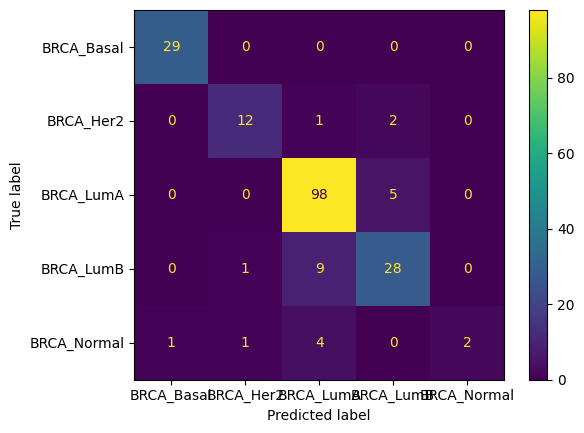

In [30]:
ConfusionMatrixDisplay(lgbm["conf_mat"], display_labels=lgbm["classes"]).plot()

### Feature Importance (Top 10 Genes)

In [31]:
lgbm["feature_data"]

,Feature,Importance
0,ENSG00000138180.14,28
1,ENSG00000261857.5,19
2,ENSG00000091831.20,17
3,ENSG00000280916.1,14
4,ENSG00000271758.2,14
5,ENSG00000115163.13,12
6,ENSG00000167711.12,12
7,ENSG00000115648.12,12
8,ENSG00000186081.10,12
9,ENSG00000264522.4,10


In [32]:
alt.Chart(lgbm["feature_data"]).mark_bar().encode(
    y=alt.Y("Feature", sort=alt.EncodingSortField(field="Importance", op="count", order="ascending"), title="Gene"),
    x=alt.X("Importance:Q"),
    color=alt.Color("Feature", legend=None),
    tooltip=["Feature", "Importance"]
).properties(title="LightGBM Top 10 Feature Importances")

alt.Chart(...)

---
## 2.5 Stacking Ensemble (Improved)
Base learners: Random Forest + XGBoost + LightGBM. Meta-learner selected via 5-fold CV, with and without passthrough.

In [50]:
with open("models/stacking_improved_results.pkl", "rb") as f:
    stk = pickle.load(f)

print(f"Stacking (Improved) Accuracy : {stk['accuracy']:.4f}")
print(f"Best meta-learner            : {stk['best_meta_name']}")
print(f"Passthrough                  : {stk['use_passthrough']}")

Stacking (Improved) Accuracy : 0.8808
Best meta-learner            : random_forest
Passthrough                  : False


### Meta-Learner CV Comparison

### Base Learner Accuracies (standalone)

In [34]:
stk["base_acc_df"]

,model,accuracy
0,random_forest,0.860104
1,xgboost,0.875648
2,lightgbm,0.891192


In [35]:
alt.Chart(stk["base_acc_df"]).mark_bar().encode(
    alt.X("model", title="Model"),
    alt.Y("accuracy", title="Accuracy", scale=alt.Scale(zero=False)),
    color="model",
    tooltip=["model", "accuracy"]
).properties(title="Base Learner Accuracies", width=300, height=250)

alt.Chart(...)

### Base Learner vs Stacking — Accuracy Comparison

### Meta-Learner CV Results — No Passthrough

In [36]:
stk["meta_results_no_passthrough"]

,meta_learner,mean_cv_accuracy,std_cv_accuracy
1,random_forest,0.895977,0.012910
2,xgboost,0.890782,0.008249
0,logistic_regression,0.881674,0.017943


In [37]:
bars = alt.Chart(stk["meta_results_no_passthrough"]).mark_bar().encode(
    alt.X("meta_learner", title="Meta-Learner"),
    alt.Y("mean_cv_accuracy", title="Mean CV Accuracy", scale=alt.Scale(zero=False)),
    color="meta_learner",
    tooltip=["meta_learner", "mean_cv_accuracy", "std_cv_accuracy"]
)
errors = alt.Chart(stk["meta_results_no_passthrough"]).mark_errorbar().encode(
    alt.X("meta_learner"),
    alt.Y("mean_cv_accuracy", scale=alt.Scale(zero=False)),
    alt.YError("std_cv_accuracy")
)
(bars + errors).properties(title="Meta-Learner CV Accuracy (no passthrough)", width=300, height=250)

alt.LayerChart(...)

### Meta-Learner CV Results — With Passthrough

In [38]:
stk["meta_results_passthrough"]

,meta_learner,mean_cv_accuracy,std_cv_accuracy
2,xgboost,0.889466,0.018934
1,random_forest,0.841389,0.018385
0,logistic_regression,0.777617,0.022422


In [39]:
bars = alt.Chart(stk["meta_results_passthrough"]).mark_bar().encode(
    alt.X("meta_learner", title="Meta-Learner"),
    alt.Y("mean_cv_accuracy", title="Mean CV Accuracy", scale=alt.Scale(zero=False)),
    color="meta_learner",
    tooltip=["meta_learner", "mean_cv_accuracy", "std_cv_accuracy"]
)
errors = alt.Chart(stk["meta_results_passthrough"]).mark_errorbar().encode(
    alt.X("meta_learner"),
    alt.Y("mean_cv_accuracy", scale=alt.Scale(zero=False)),
    alt.YError("std_cv_accuracy")
)
(bars + errors).properties(title="Meta-Learner CV Accuracy (with passthrough)", width=300, height=250)

alt.LayerChart(...)

### Confusion Matrix

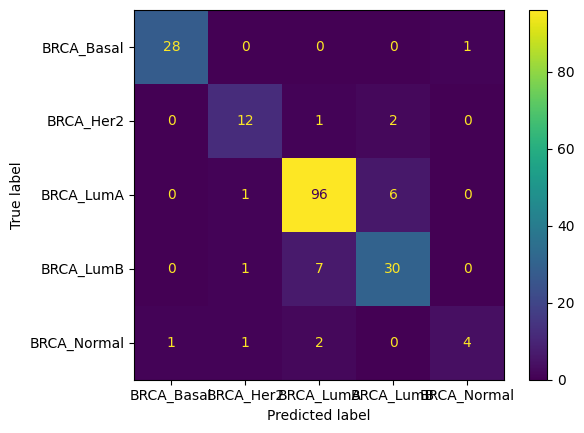

In [40]:
ConfusionMatrixDisplay(stk["conf_mat"], display_labels=stk["classes"]).plot()

### t-SNE Visualization of Ensemble Predictions

In [53]:
from sklearn.manifold import TSNE
import numpy as np

# Apply t-SNE to test data
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_results = tsne.fit_transform(stk["X_test"])

# Create dataframe for visualization
tsne_df = pd.DataFrame({
    'tsne_1': tsne_results[:, 0],
    'tsne_2': tsne_results[:, 1],
    'True_Label': stk["y_test"],
    'Predicted_Label': stk["y_pred"],
    'Correct': stk["y_test"] == stk["y_pred"]
})

# Chart 1: Colored by True Labels
true_labels_chart = alt.Chart(tsne_df).mark_circle(size=60).encode(
    x=alt.X('tsne_1:Q', title='t-SNE 1'),
    y=alt.Y('tsne_2:Q', title='t-SNE 2'),
    color=alt.Color('True_Label:N', title='True Subtype'),
    tooltip=['True_Label', 'Predicted_Label', 'Correct']
).properties(
    title='t-SNE: Test Data (True Labels)',
    width=400,
    height=400
)

# Chart 2: Colored by Predicted Labels
pred_labels_chart = alt.Chart(tsne_df).mark_circle(size=60).encode(
    x=alt.X('tsne_1:Q', title='t-SNE 1'),
    y=alt.Y('tsne_2:Q', title='t-SNE 2'),
    color=alt.Color('Predicted_Label:N', title='Predicted Subtype'),
    tooltip=['True_Label', 'Predicted_Label', 'Correct']
).properties(
    title='t-SNE: Ensemble Predictions',
    width=400,
    height=400
)

# Display side by side
true_labels_chart | pred_labels_chart

alt.HConcatChart(...)

In [54]:
# Prediction accuracy summary
correct_predictions = (tsne_df['True_Label'] == tsne_df['Predicted_Label']).sum()
total_predictions = len(tsne_df)
accuracy_pct = (correct_predictions / total_predictions) * 100

print(f"Correct Predictions: {correct_predictions}/{total_predictions} ({accuracy_pct:.2f}%)")
print(f"\nPrediction Distribution:")
print(tsne_df['Predicted_Label'].value_counts().sort_index())

Correct Predictions: 170/193 (88.08%)

Prediction Distribution:
Predicted_Label
BRCA_Basal      29
BRCA_Her2       15
BRCA_LumA      106
BRCA_LumB       38
BRCA_Normal      5
Name: count, dtype: int64


### 3D t-SNE Visualization (Interactive)

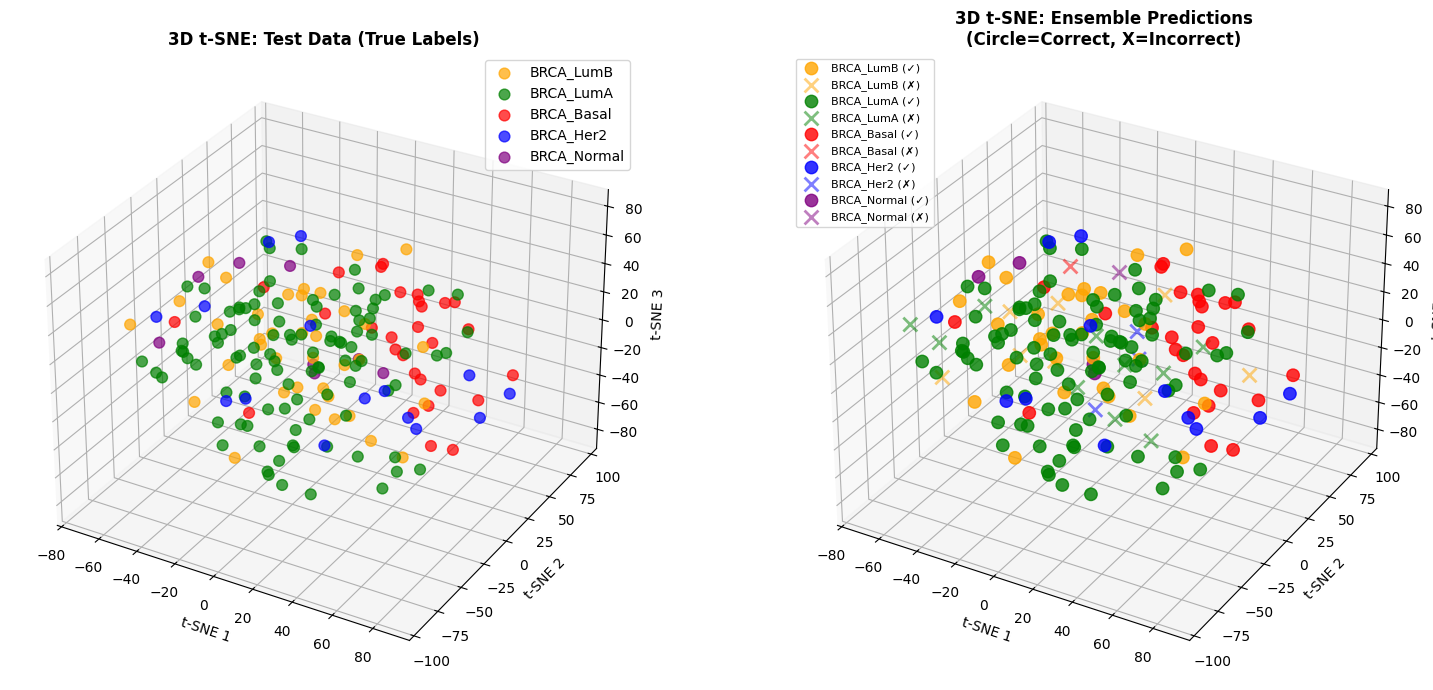

3D t-SNE Visualization Complete!


In [58]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Apply 3D t-SNE to test data
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000)
tsne_results_3d = tsne_3d.fit_transform(stk["X_test"])

# Create dataframe for 3D visualization
tsne_df_3d = pd.DataFrame({
    'tsne_1': tsne_results_3d[:, 0],
    'tsne_2': tsne_results_3d[:, 1],
    'tsne_3': tsne_results_3d[:, 2],
    'True_Label': stk["y_test"],
    'Predicted_Label': stk["y_pred"],
    'Correct': stk["y_test"] == stk["y_pred"]
})

# Define color mapping
color_map = {
    'BRCA_Basal': 'red',
    'BRCA_Her2': 'blue',
    'BRCA_LumA': 'green',
    'BRCA_LumB': 'orange',
    'BRCA_Normal': 'purple'
}

# Create figure with two 3D subplots
fig = plt.figure(figsize=(16, 7))

# Plot 1: True Labels
ax1 = fig.add_subplot(121, projection='3d')
for label in tsne_df_3d['True_Label'].unique():
    mask = tsne_df_3d['True_Label'] == label
    ax1.scatter(
        tsne_df_3d[mask]['tsne_1'],
        tsne_df_3d[mask]['tsne_2'],
        tsne_df_3d[mask]['tsne_3'],
        c=color_map.get(label, 'gray'),
        label=label,
        s=60,
        alpha=0.7
    )
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_zlabel('t-SNE 3')
ax1.set_title('3D t-SNE: Test Data (True Labels)', fontsize=12, fontweight='bold')
ax1.legend()

# Plot 2: Predicted Labels (with correct/incorrect distinction)
ax2 = fig.add_subplot(122, projection='3d')
for label in tsne_df_3d['Predicted_Label'].unique():
    mask = tsne_df_3d['Predicted_Label'] == label
    correct_mask = tsne_df_3d[mask]['Correct']
    
    # Correct predictions
    ax2.scatter(
        tsne_df_3d[mask][correct_mask]['tsne_1'],
        tsne_df_3d[mask][correct_mask]['tsne_2'],
        tsne_df_3d[mask][correct_mask]['tsne_3'],
        c=color_map.get(label, 'gray'),
        label=f'{label} (✓)',
        s=80,
        alpha=0.8,
        marker='o'
    )
    
    # Incorrect predictions (marked with X)
    if (~correct_mask).sum() > 0:
        ax2.scatter(
            tsne_df_3d[mask][~correct_mask]['tsne_1'],
            tsne_df_3d[mask][~correct_mask]['tsne_2'],
            tsne_df_3d[mask][~correct_mask]['tsne_3'],
            c=color_map.get(label, 'gray'),
            label=f'{label} (✗)',
            s=100,
            alpha=0.5,
            marker='x',
            linewidths=2
        )

ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_zlabel('t-SNE 3')
ax2.set_title('3D t-SNE: Ensemble Predictions\n(Circle=Correct, X=Incorrect)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print("3D t-SNE Visualization Complete!")

### Training and Validation Accuracy Across Epochs

In [51]:
# Check available keys in stacking results
print("Available keys in stacking results:", list(stk.keys()))

Available keys in stacking results: ['model', 'X_test', 'y_test', 'y_pred', 'classes', 'accuracy', 'conf_mat', 'meta_results_no_passthrough', 'meta_results_passthrough', 'base_acc_df', 'comparison_df', 'best_meta_name', 'use_passthrough']


In [41]:
stk["comparison_df"]

,model,accuracy
0,lightgbm,0.891192
1,"stacking (random_forest, passthrough=False)",0.880829
2,xgboost,0.875648
3,random_forest,0.860104


In [42]:
alt.Chart(stk["comparison_df"]).mark_bar().encode(
    alt.X("model", title="Model", sort="-y"),
    alt.Y("accuracy", title="Accuracy", scale=alt.Scale(zero=False)),
    color="model",
    tooltip=["model", "accuracy"]
).properties(title="Accuracy: Base Learners vs Stacking", width=400, height=280)

alt.Chart(...)

**Stacking (Improved) Observations**\
Adding LightGBM as a third base learner and testing passthrough gives the meta-learner access to richer signal.\
Compare the best meta-learner with and without passthrough — if passthrough wins, the meta-learner is benefiting directly from the raw gene expression features on top of the base predictions.

---

## 2.6 Neural Network

In [43]:
with open('models/nn_results.pkl', 'rb') as f:
    nn = pickle.load(f)

print(f"Neural Network Test Accuracy: {nn['accuracy']:.4f}")

Neural Network Test Accuracy: 0.8290


### Confusion matrix

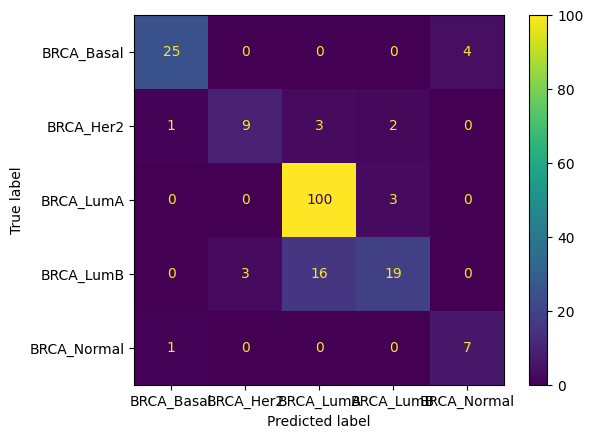

In [44]:
ConfusionMatrixDisplay(nn["conf_mat"], display_labels=nn["classes"]).plot()

### Hyperparameter Search Plots

In [45]:
# Learning Rate Plot
lr_chart = alt.Chart(nn["lr_df"]).mark_line(point=True).encode(
    x=alt.X('learning_rate:Q', title='Learning Rate'),
    y=alt.Y('Accuracy:Q', title='Validation Accuracy'),
    tooltip=['learning_rate', 'Accuracy']
).properties(
    title="Learning Rate vs Accuracy",
    width=300,
    height=250
)

# Dropout Plot
drop_chart = alt.Chart(nn["dropout_df"]).mark_line(point=True).encode(
    x=alt.X('dropout:Q', title='Dropout'),
    y=alt.Y('Accuracy:Q', title='Validation Accuracy'),
    tooltip=['dropout', 'Accuracy']
).properties(
    title="Dropout vs Accuracy",
    width=300,
    height=250
)

# Combine side by side
lr_chart | drop_chart

alt.HConcatChart(...)